In [1]:
# Install libraries (Colab has most already)
!pip install scikit-learn --quiet

# Import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load the CSV file
df = pd.read_csv('Titanic-Dataset.csv')

# Show first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# How many rows and columns?
print("Shape:", df.shape)

# What columns do we have?
print("\nColumns:", df.columns.tolist())

# Are there any missing values?
print("\nMissing values:")
print(df.isnull().sum())

Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


/tmp/ipykernel_1723/2402079984.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


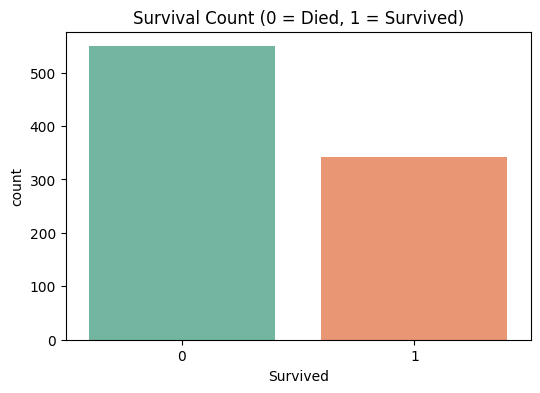

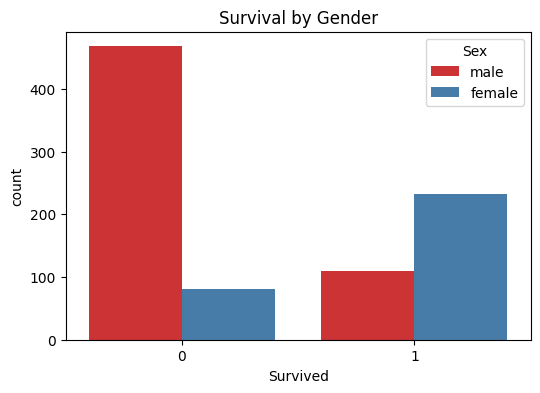

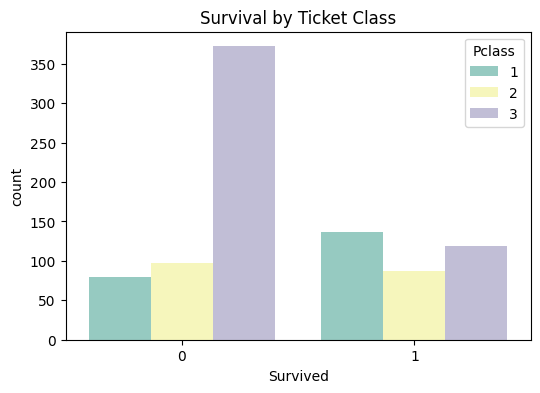

In [4]:
# Chart 1: How many survived?
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.show()

# Chart 2: Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Sex', data=df, palette='Set1')
plt.title('Survival by Gender')
plt.show()

# Chart 3: Survival by Ticket Class
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Pclass', data=df, palette='Set3')
plt.title('Survival by Ticket Class')
plt.show()

In [5]:
# Fill missing Age with median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked with most common port
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column (too many missing values - over 70%)
df.drop(columns=['Cabin'], inplace=True)

# Confirm all missing values are fixed
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\n✅ Data cleaned successfully!")

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

✅ Data cleaned successfully!


/tmp/ipykernel_1723/3280562242.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1723/3280562242.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [6]:
# Convert text to numbers (ML models only understand numbers)

# Sex: male = 0, female = 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Embarked port: S = 0, C = 1, Q = 2
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Choose which columns to use for prediction
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[features]   # Input features
y = df['Survived'] # What we want to predict

print("✅ Features ready!")
print("X shape:", X.shape)
print("y shape:", y.shape)

✅ Features ready!
X shape: (891, 7)
y shape: (891,)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("✅ Data split successfully!")

Training samples: 712
Testing samples: 179
✅ Data split successfully!


In [ ]:

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [ ]:

y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

🎯 Model Accuracy: 79.89%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



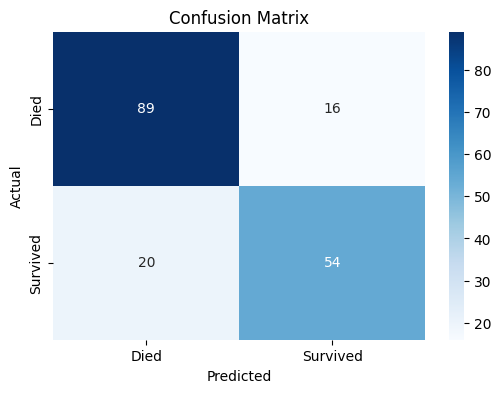

In [ ]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:


new_passenger = pd.DataFrame([[3, 0, 22, 1, 0, 7.25, 0]],
                               columns=features)

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("✅ This passenger SURVIVED!")
else:
    print("❌ This passenger did NOT survive.")

❌ This passenger did NOT survive.
